# Unsupervised Disease Subgroup Discovery from Health Data
**ARTI 308 – Machine Learning | Group 4**

| # | Name | ID | Role |
|---|------|----|------|
| 1 | Wesam Jaber Almalki | 2240005660 | Leader |
| 2 | Fahad Nawar Alotaibi | 2240002024 | Member |
| 3 | Fawaz Alshahrani | 2240005571 | Member |
| 4 | Faris Alshahrani | 2240005572 | Member |
| 5 | Ahmed Albouainain | 2240006128 | Member |
| 6 | Anas Hamzi | 2240003869 | Member |

---
**Objective:** Apply unsupervised learning (K-Means, Hierarchical Clustering, GMM, DBSCAN) with PCA dimensionality reduction on three key clinical biomarkers — **BMI**, **Fasting Glucose**, and **Systolic Blood Pressure** — to discover natural patient groupings that correspond to hypertension, type II diabetes, and obesity-related risk, without using disease labels during training.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

---
## 1. Load Data

In [2]:
import os, glob

# Auto-locate the CSV regardless of working directory (local or Colab)
_csv_name = "dataset for machine project.csv"
_candidates = [
    f"dataset/{_csv_name}",
    f"../{_csv_name}",
    f"../dataset/{_csv_name}",
    _csv_name,
]
_found = next((p for p in _candidates if os.path.exists(p)), None)
if _found is None:
    _hits = glob.glob(f"**/{_csv_name}", recursive=True)
    _found = _hits[0] if _hits else None
if _found is None:
    raise FileNotFoundError(
        f"Cannot find '{_csv_name}'.\n"
        "On Colab: upload the file or run:\n"
        "  from google.colab import files; files.upload()"
    )
print(f"Dataset found at: {_found}")
df = pd.read_csv(_found)

# Drop any all-NaN trailing columns from CSV export artifacts
df = df.dropna(axis=1, how="all")
# Drop rows with missing values in the three biomarkers
df = df.dropna(subset=["BMI", "Glucose_mg/dL", "Blood_Pressure_mmHg"]).reset_index(drop=True)

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumns:\n{list(df.columns)}")
print(f"\nMissing values:\n{df.isnull().sum().sum()} total")
print(f"\nData types:\n{df.dtypes.value_counts()}")

Dataset found at: dataset/dataset for machine project.csv
DATASET OVERVIEW
Shape: 1000 rows × 4 columns

Columns:
['BMI', 'Disease_Type', 'Blood_Pressure_mmHg', 'Glucose_mg/dL']

Missing values:
0 total

Data types:
float64    2
str        1
int64      1
Name: count, dtype: int64


---
## 2. Exploratory Data Analysis
Inspect distributions of categorical and numerical features before modelling.


EXPLORATORY DATA ANALYSIS

Numerical summary:
           BMI  Blood_Pressure_mmHg  Glucose_mg/dL
count  1000.00              1000.00        1000.00
mean     28.19               149.26         118.69
std       8.04                13.06          25.39
min      13.00               125.00          85.10
25%      22.08               139.00         101.00
50%      27.45               149.00         111.45
75%      33.42               159.00         131.18
max      52.40               179.00         199.80

Disease_Type distribution:
Disease_Type
Hypertension    398
Obesity         393
Diabetes        209
Name: count, dtype: int64


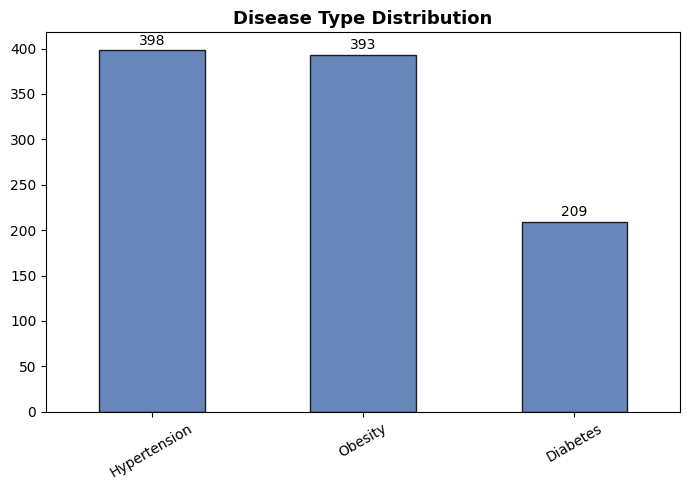

In [3]:
print("\n" + "=" * 60)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)

print("\nNumerical summary:")
print(df.describe().round(2))

print("\nDisease_Type distribution:")
print(df["Disease_Type"].value_counts())

# Plot disease distribution
fig, ax = plt.subplots(figsize=(7, 5))
counts = df["Disease_Type"].value_counts()
counts.plot(kind="bar", ax=ax, color="#4C72B0", edgecolor="black", alpha=0.85)
ax.set_title("Disease Type Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=30)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 3, int(bar.get_height()),
            ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig("eda_categorical.png", dpi=150)
plt.show()

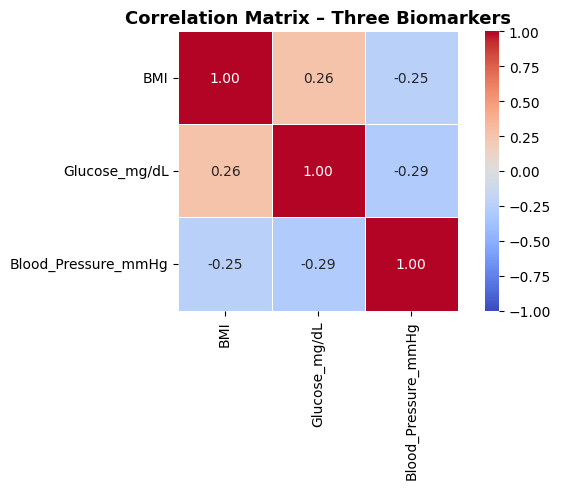

In [4]:
# Correlation heatmap — the three biomarkers
num_cols = ["BMI", "Glucose_mg/dL", "Blood_Pressure_mmHg"]

plt.figure(figsize=(7, 5))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, vmin=-1, vmax=1, square=True)
plt.title("Correlation Matrix – Three Biomarkers", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_correlation.png", dpi=150)
plt.show()

---
## 3. Preprocessing & Feature Engineering
- `Disease_Type` excluded from clustering, saved for post-hoc validation only
- Three clinical biomarkers used as input features:
  - `BMI` — body mass index (kg/m²)
  - `Glucose_mg/dL` — fasting glucose
  - `Blood_Pressure_mmHg` — systolic blood pressure
- All features standardized with `StandardScaler` (zero mean, unit variance)

In [5]:
print("\n" + "=" * 60)
print("PREPROCESSING")
print("=" * 60)

# Disease_Type saved for post-hoc validation only
labels_disease = df["Disease_Type"].copy()

# Three clinically relevant biomarkers
numerical = ["BMI", "Glucose_mg/dL", "Blood_Pressure_mmHg"]
df_encoded = df[numerical].copy()

print(f"Features ({len(numerical)}): {numerical}")
print(f"Feature matrix shape: {df_encoded.shape}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)
print("Standardization complete.")


PREPROCESSING
Features (3): ['BMI', 'Glucose_mg/dL', 'Blood_Pressure_mmHg']
Feature matrix shape: (1000, 3)
Standardization complete.


---
## 4. Dimensionality Reduction
With only three features, no reduction is needed for modelling, but PCA and t-SNE projections to 2D help visualize the cluster structure.


DIMENSIONALITY REDUCTION
Components needed for 95% variance: 3


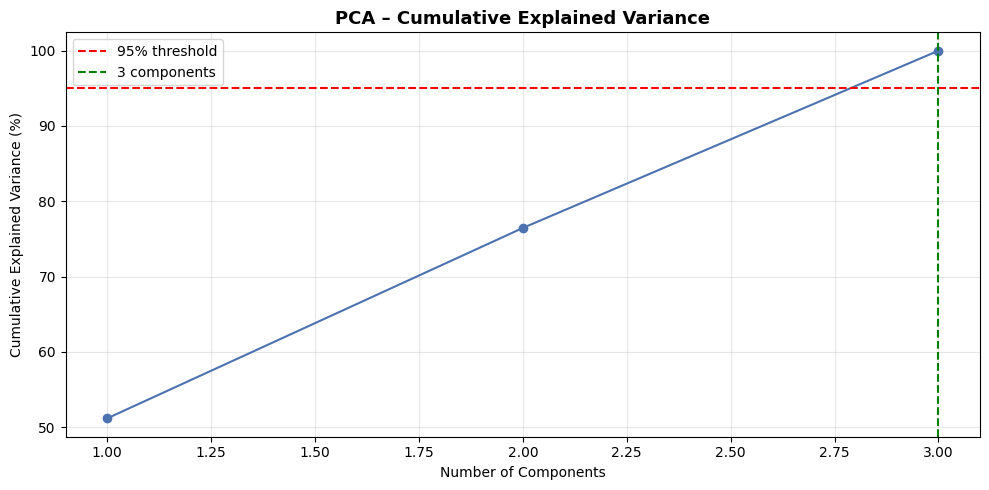

PCA 2D variance explained: 76.5%
Running t-SNE (this may take a moment)...
t-SNE complete.


In [6]:
print("\n" + "=" * 60)
print("DIMENSIONALITY REDUCTION")
print("=" * 60)

# PCA – explained variance
pca_full = PCA()
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumvar >= 0.95) + 1
print(f"Components needed for 95% variance: {n_components_95}")

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumvar) + 1), cumvar * 100, marker="o", color="#4C72B0")
plt.axhline(95, color="red", linestyle="--", label="95% threshold")
plt.axvline(n_components_95, color="green", linestyle="--",
            label=f"{n_components_95} components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("PCA \u2013 Cumulative Explained Variance", fontsize=13, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("pca_variance.png", dpi=150)
plt.show()

# Reduce to 2D for visualization
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)
print(f"PCA 2D variance explained: {pca_2d.explained_variance_ratio_.sum():.1%}")

# t-SNE 2D
print("Running t-SNE (this may take a moment)...")
tsne = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)
print("t-SNE complete.")

---
## 5. K-Means Clustering – Finding Optimal K
Three metrics are used to identify the best number of clusters:
- **Elbow Method** (Inertia / WSS)
- **Silhouette Score** (higher = better)
- **Davies-Bouldin Index** (lower = better)


K-MEANS – FINDING OPTIMAL K
  K=2  Inertia=1857  Silhouette=0.3517  DBI=1.1332
  K=3  Inertia=1358  Silhouette=0.3649  DBI=1.0176
  K=4  Inertia=982  Silhouette=0.3732  DBI=0.9387
  K=5  Inertia=804  Silhouette=0.3543  DBI=1.0231
  K=6  Inertia=698  Silhouette=0.3426  DBI=1.0011
  K=7  Inertia=631  Silhouette=0.3092  DBI=1.0566
  K=8  Inertia=563  Silhouette=0.3101  DBI=1.0351
  K=9  Inertia=517  Silhouette=0.3061  DBI=1.0556
  K=10  Inertia=481  Silhouette=0.3032  DBI=1.0304


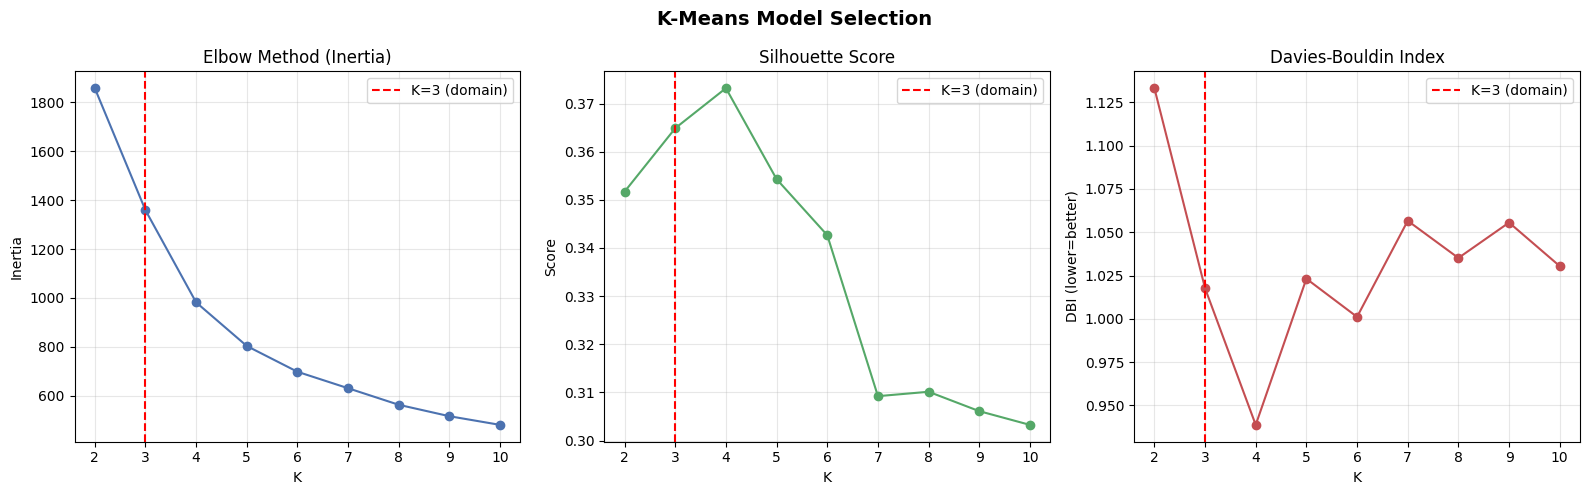


Selected K = 3  (domain knowledge: Hypertension / Obesity / Diabetes)


In [7]:
print("\n" + "=" * 60)
print("K-MEANS – FINDING OPTIMAL K")
print("=" * 60)

inertias, silhouettes, dbi_scores = [], [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    dbi_scores.append(davies_bouldin_score(X_scaled, labels))
    print(f"  K={k}  Inertia={km.inertia_:.0f}  "
          f"Silhouette={silhouettes[-1]:.4f}  DBI={dbi_scores[-1]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("K-Means Model Selection", fontsize=14, fontweight="bold")

axes[0].plot(K_range, inertias, marker="o", color="#4C72B0")
axes[0].axvline(3, color="red", linestyle="--", label="K=3 (domain)")
axes[0].set_title("Elbow Method (Inertia)")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(K_range, silhouettes, marker="o", color="#55A868")
axes[1].axvline(3, color="red", linestyle="--", label="K=3 (domain)")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Score")
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(K_range, dbi_scores, marker="o", color="#C44E52")
axes[2].axvline(3, color="red", linestyle="--", label="K=3 (domain)")
axes[2].set_title("Davies-Bouldin Index")
axes[2].set_xlabel("K"); axes[2].set_ylabel("DBI (lower=better)")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("kmeans_selection.png", dpi=150)
plt.show()

# Domain knowledge override: dataset has 3 known disease groups
best_k = 3
print(f"\nSelected K = {best_k}  (domain knowledge: Hypertension / Obesity / Diabetes)")

---
## 6. Final K-Means Model
Train the final K-Means model using the optimal K and visualize clusters via PCA and t-SNE projections.


FINAL K-MEANS MODEL  (K=3)
Silhouette Score : 0.3649
Davies-Bouldin   : 1.0176
Inertia          : 1358.46

Cluster → Disease mapping: {0: 'Hypertension', 1: 'Obesity', 2: 'Diabetes'}
Cluster sizes: {'Diabetes': np.int64(142), 'Hypertension': np.int64(410), 'Obesity': np.int64(448)}


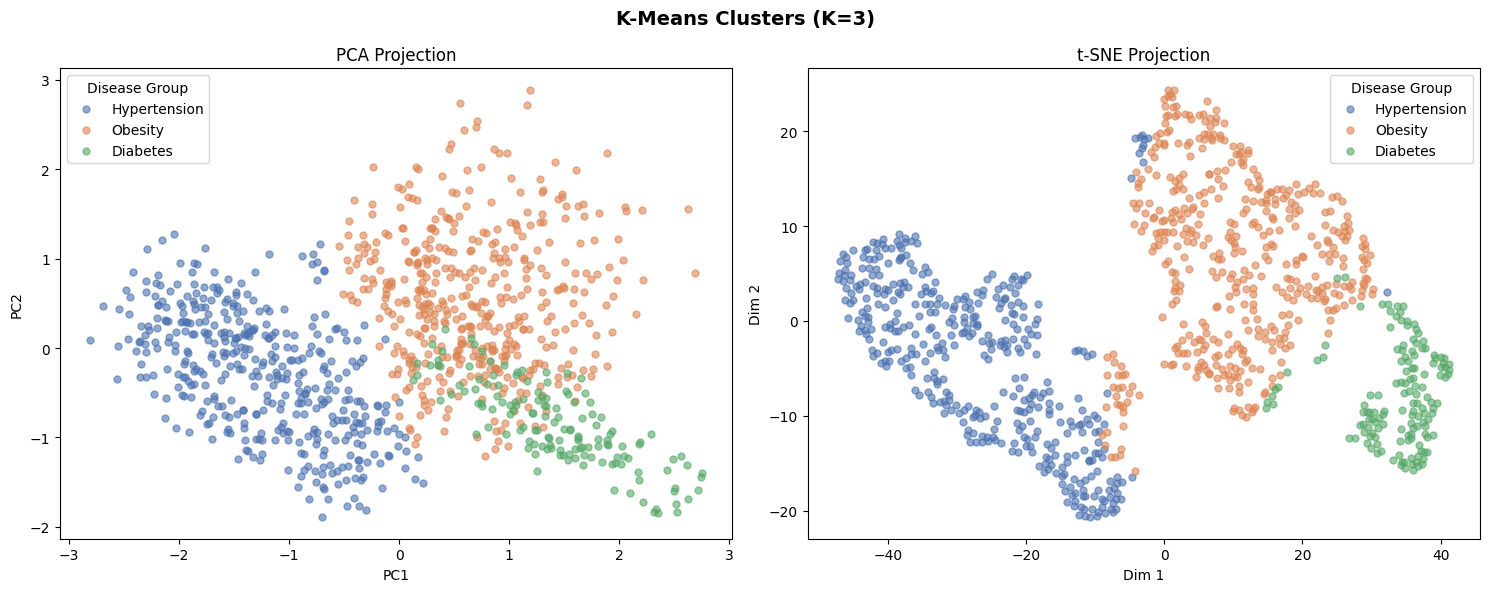

In [8]:
print("\n" + "=" * 60)
print(f"FINAL K-MEANS MODEL  (K={best_k})")
print("=" * 60)

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_labels = km_final.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, km_labels)
dbi = davies_bouldin_score(X_scaled, km_labels)
print(f"Silhouette Score : {sil:.4f}")
print(f"Davies-Bouldin   : {dbi:.4f}")
print(f"Inertia          : {km_final.inertia_:.2f}")

# Map each cluster number → dominant disease name
ct_km = pd.crosstab(km_labels, labels_disease)
km_map  = {c: ct_km.loc[c].idxmax() for c in ct_km.index}
km_named = pd.Series(km_labels).map(km_map).values
print(f"\nCluster → Disease mapping: {km_map}")
print(f"Cluster sizes: {dict(zip(*np.unique(km_named, return_counts=True)))}")

# Visualize with disease names as legend
disease_colors = {"Hypertension": "#4C72B0", "Obesity": "#DD8452", "Diabetes": "#55A868"}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"K-Means Clusters (K={best_k})", fontsize=14, fontweight="bold")

for disease, color in disease_colors.items():
    mask = km_named == disease
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=disease, alpha=0.6, s=25)
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    c=color, label=disease, alpha=0.6, s=25)

for ax, title in zip(axes, ["PCA Projection", "t-SNE Projection"]):
    ax.set_title(title); ax.legend(title="Disease Group")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[1].set_xlabel("Dim 1"); axes[1].set_ylabel("Dim 2")

plt.tight_layout()
plt.savefig("kmeans_clusters.png", dpi=150)
plt.show()

---
## 7. Hierarchical Clustering
Ward linkage dendrogram on a 200-sample subset, then Agglomerative Clustering fitted on the full dataset using the same K.


HIERARCHICAL CLUSTERING


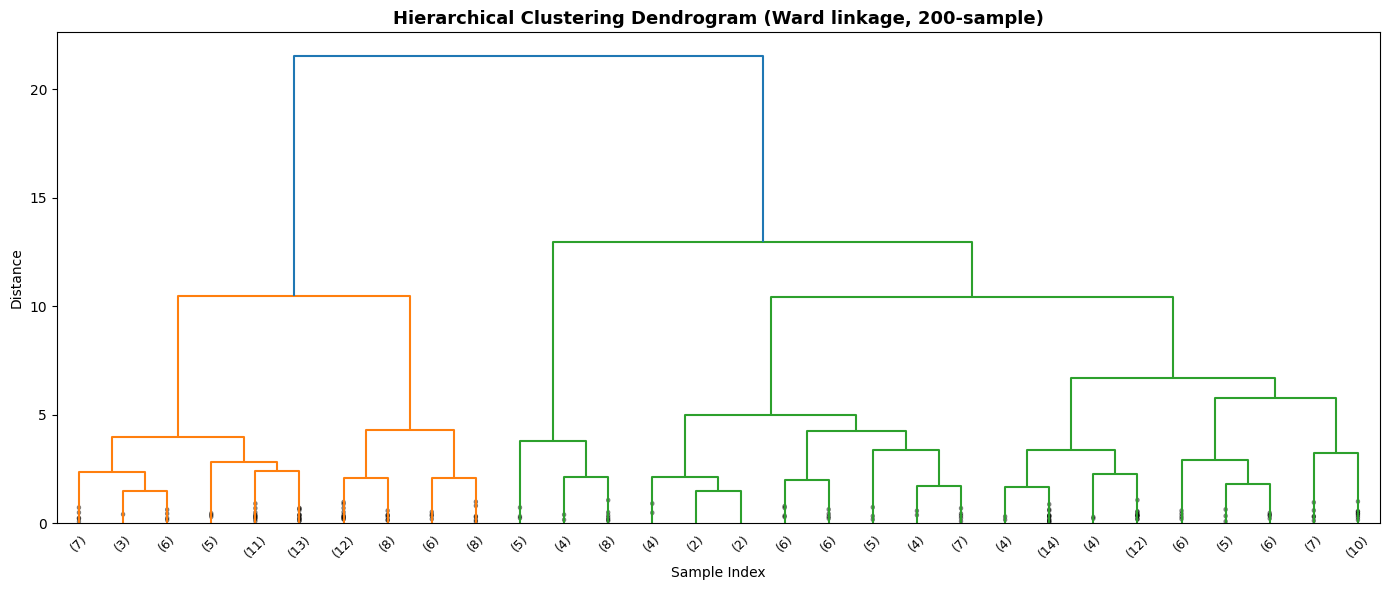

Silhouette Score : 0.3567
Davies-Bouldin   : 1.0251
Cluster → Disease mapping: {0: 'Hypertension', 1: 'Obesity', 2: 'Diabetes'}
Cluster sizes: {'Diabetes': np.int64(115), 'Hypertension': np.int64(428), 'Obesity': np.int64(457)}


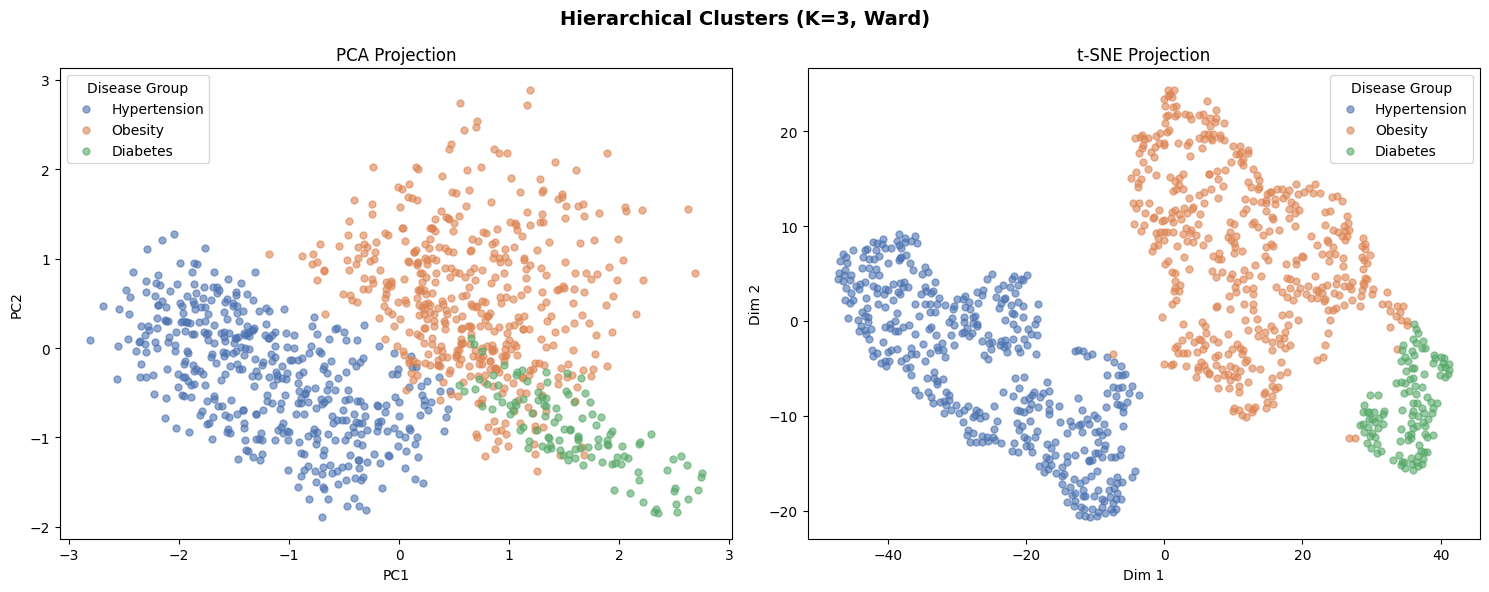

In [9]:
print("\n" + "=" * 60)
print("HIERARCHICAL CLUSTERING")
print("=" * 60)

# Dendrogram (sample 200 for readability)
sample_idx = np.random.choice(len(X_scaled), 200, replace=False)
Z = linkage(X_scaled[sample_idx], method="ward")

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=45,
           leaf_font_size=9, show_contracted=True,
           color_threshold=0.7 * max(Z[:, 2]))
plt.title("Hierarchical Clustering Dendrogram (Ward linkage, 200-sample)",
          fontsize=13, fontweight="bold")
plt.xlabel("Sample Index"); plt.ylabel("Distance")
plt.tight_layout()
plt.savefig("hierarchical_dendrogram.png", dpi=150)
plt.show()

# Agglomerative with K=3
agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
agg_labels = agg.fit_predict(X_scaled)

sil_agg = silhouette_score(X_scaled, agg_labels)
dbi_agg = davies_bouldin_score(X_scaled, agg_labels)
print(f"Silhouette Score : {sil_agg:.4f}")
print(f"Davies-Bouldin   : {dbi_agg:.4f}")

# Map cluster numbers → disease names
ct_agg  = pd.crosstab(agg_labels, labels_disease)
agg_map  = {c: ct_agg.loc[c].idxmax() for c in ct_agg.index}
agg_named = pd.Series(agg_labels).map(agg_map).values
print(f"Cluster → Disease mapping: {agg_map}")
print(f"Cluster sizes: {dict(zip(*np.unique(agg_named, return_counts=True)))}")

disease_colors = {"Hypertension": "#4C72B0", "Obesity": "#DD8452", "Diabetes": "#55A868"}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"Hierarchical Clusters (K={best_k}, Ward)", fontsize=14, fontweight="bold")

for disease, color in disease_colors.items():
    mask = agg_named == disease
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=disease, alpha=0.6, s=25)
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    c=color, label=disease, alpha=0.6, s=25)

for ax, title in zip(axes, ["PCA Projection", "t-SNE Projection"]):
    ax.set_title(title); ax.legend(title="Disease Group")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[1].set_xlabel("Dim 1"); axes[1].set_ylabel("Dim 2")

plt.tight_layout()
plt.savefig("hierarchical_clusters.png", dpi=150)
plt.show()

---
## 7.5 DBSCAN Clustering
Density-Based Spatial Clustering — does not require specifying K in advance.
- **eps** (neighbourhood radius) selected via the k-distance elbow plot
- **min_samples** = 6 (rule of thumb: 2 × n_features, here 2 × 3)
- Noise points (label = −1) are reported separately and excluded from metrics


DBSCAN CLUSTERING


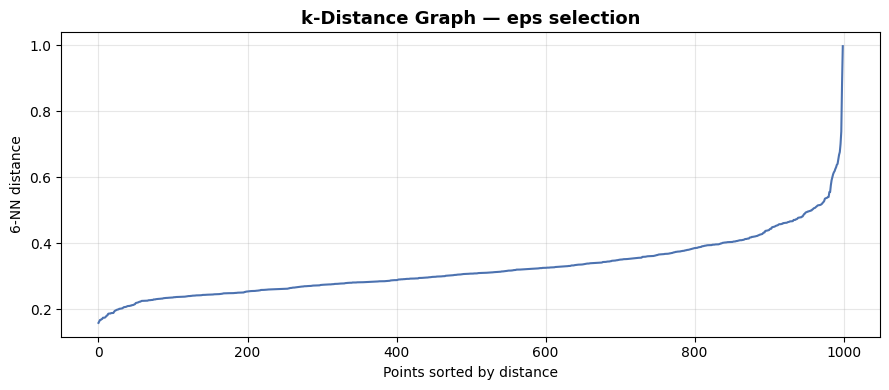

  Percentile     eps  Clusters   Noise
----------------------------------------
         40%   0.288        27     293
         50%   0.308        21     235
         60%   0.326         9     178
         70%   0.350        10     112
         80%   0.385         6      64
         90%   0.439         4      23

DBSCAN found 4 cluster(s) and 23 noise points at eps=0.439.
Silhouette (core points): 0.0845
Davies-Bouldin (core)   : 0.7124


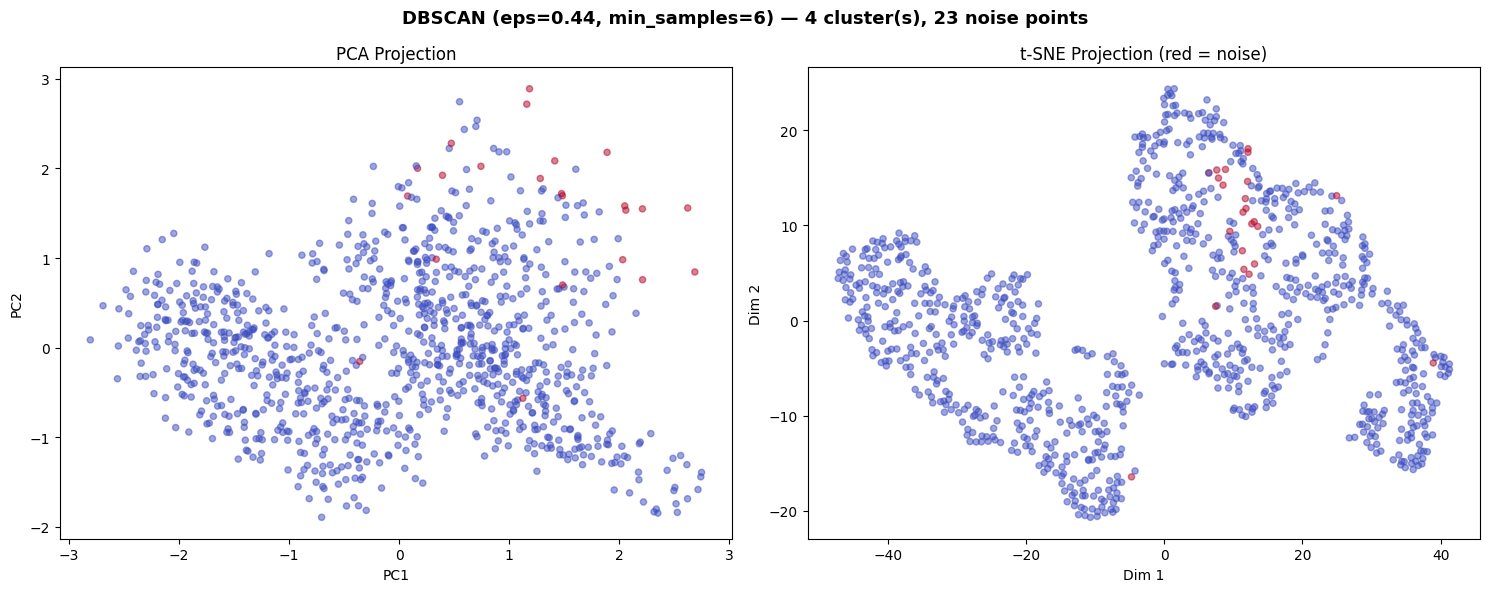

In [10]:
print("\n" + "=" * 60)
print("DBSCAN CLUSTERING")
print("=" * 60)

min_samples = 6   # 2 × n_features (3 biomarkers)

# k-distance plot for eps selection
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(9, 4))
plt.plot(k_distances, color="#4C72B0")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-NN distance")
plt.title("k-Distance Graph — eps selection", fontsize=13, fontweight="bold")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("dbscan_kdistance.png", dpi=150)
plt.show()

# Sweep eps percentiles and record cluster counts
print(f"{'Percentile':>12}  {'eps':>6}  {'Clusters':>8}  {'Noise':>6}")
print("-" * 40)
eps_results = {}
for pct in [40, 50, 60, 70, 80, 90]:
    eps_val = float(np.percentile(k_distances, pct))
    lbs = DBSCAN(eps=eps_val, min_samples=min_samples).fit_predict(X_scaled)
    n_cl = len(set(lbs)) - (1 if -1 in lbs else 0)
    n_ns = (lbs == -1).sum()
    eps_results[pct] = (eps_val, n_cl, n_ns, lbs)
    print(f"{pct:>11}%  {eps_val:>6.3f}  {n_cl:>8}  {n_ns:>6}")

# Use 90th-percentile result as the representative run
eps, n_clusters_db, n_noise, db_labels = eps_results[90]
mask_core = db_labels != -1

print(f"\nDBSCAN found {n_clusters_db} cluster(s) and {n_noise} noise points at eps={eps:.3f}.")
if n_clusters_db <= 1:
    print("Indicates uniform density — K-Means / Hierarchical / GMM better suited to this dataset.")
    sil_db, dbi_db = np.nan, np.nan
else:
    sil_db = silhouette_score(X_scaled[mask_core], db_labels[mask_core])
    dbi_db = davies_bouldin_score(X_scaled[mask_core], db_labels[mask_core])
    print(f"Silhouette (core points): {sil_db:.4f}")
    print(f"Davies-Bouldin (core)   : {dbi_db:.4f}")

# Visualize the DBSCAN result (noise vs core)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"DBSCAN (eps={eps:.2f}, min_samples={min_samples}) — {n_clusters_db} cluster(s), {n_noise} noise points",
             fontsize=13, fontweight="bold")

colors_db = np.where(db_labels == -1, 0.5, 0.1)
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_db, cmap="coolwarm", alpha=0.5, s=20)
axes[0].set_title("PCA Projection"); axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors_db, cmap="coolwarm", alpha=0.5, s=20)
axes[1].set_title("t-SNE Projection (red = noise)"); axes[1].set_xlabel("Dim 1"); axes[1].set_ylabel("Dim 2")

plt.tight_layout()
plt.savefig("dbscan_clusters.png", dpi=150)
plt.show()

---
## 7.6 Gaussian Mixture Model (GMM)
Probabilistic soft-clustering — each patient is assigned a probability of belonging to each cluster rather than a hard label.
Better suited than K-Means for overlapping groups (e.g., Diabetes/Obesity patients who share metabolic features).


GAUSSIAN MIXTURE MODEL (GMM)
Silhouette Score : 0.3635
Davies-Bouldin   : 1.0182
BIC              : 7297.45  (lower = better fit)
AIC              : 7155.12  (lower = better fit)

Mean max-probability per point: 0.958
(1.0 = fully confident, 0.33 = completely uncertain)

Cluster → Disease mapping: {0: 'Hypertension', 1: 'Obesity', 2: 'Diabetes'}
Cluster sizes: {'Diabetes': np.int64(136), 'Hypertension': np.int64(402), 'Obesity': np.int64(462)}


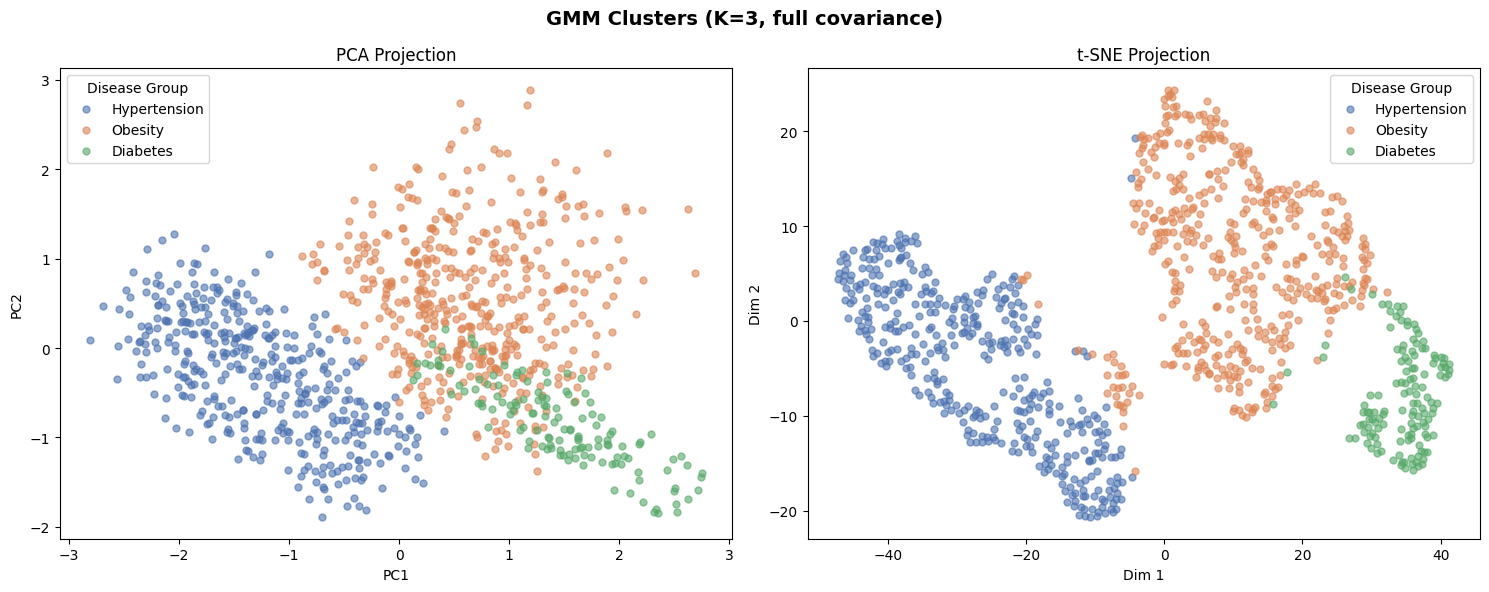


GMM Cluster vs Disease_Type (post-hoc validation):
Disease_Type      Diabetes  Hypertension  Obesity
Discovered Group                                 
Diabetes               136             0        0
Hypertension             9           393        0
Obesity                 64             5      393


In [11]:
print("\n" + "=" * 60)
print("GAUSSIAN MIXTURE MODEL (GMM)")
print("=" * 60)

gmm = GaussianMixture(n_components=best_k, covariance_type="full",
                      random_state=42, n_init=10)
gmm_labels = gmm.fit_predict(X_scaled)

sil_gmm = silhouette_score(X_scaled, gmm_labels)
dbi_gmm = davies_bouldin_score(X_scaled, gmm_labels)
print(f"Silhouette Score : {sil_gmm:.4f}")
print(f"Davies-Bouldin   : {dbi_gmm:.4f}")
print(f"BIC              : {gmm.bic(X_scaled):.2f}  (lower = better fit)")
print(f"AIC              : {gmm.aic(X_scaled):.2f}  (lower = better fit)")

probs = gmm.predict_proba(X_scaled)
print(f"\nMean max-probability per point: {probs.max(axis=1).mean():.3f}")
print("(1.0 = fully confident, 0.33 = completely uncertain)")

# Map cluster numbers → disease names
ct_gmm   = pd.crosstab(gmm_labels, labels_disease)
gmm_map  = {c: ct_gmm.loc[c].idxmax() for c in ct_gmm.index}
gmm_named = pd.Series(gmm_labels).map(gmm_map).values
print(f"\nCluster → Disease mapping: {gmm_map}")
print(f"Cluster sizes: {dict(zip(*np.unique(gmm_named, return_counts=True)))}")

disease_colors = {"Hypertension": "#4C72B0", "Obesity": "#DD8452", "Diabetes": "#55A868"}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"GMM Clusters (K={best_k}, full covariance)", fontsize=14, fontweight="bold")

for disease, color in disease_colors.items():
    mask = gmm_named == disease
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=disease, alpha=0.6, s=25)
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    c=color, label=disease, alpha=0.6, s=25)

for ax, title in zip(axes, ["PCA Projection", "t-SNE Projection"]):
    ax.set_title(title); ax.legend(title="Disease Group")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[1].set_xlabel("Dim 1"); axes[1].set_ylabel("Dim 2")

plt.tight_layout()
plt.savefig("gmm_clusters.png", dpi=150)
plt.show()

print("\nGMM Cluster vs Disease_Type (post-hoc validation):")
print(pd.crosstab(gmm_named, labels_disease, rownames=["Discovered Group"]))

---
## 8. Algorithm Comparison
Side-by-side comparison of all four clustering algorithms (K-Means, Hierarchical Ward, GMM, DBSCAN) on both **internal** and **external** validation metrics.

**Internal metrics** (no ground-truth labels needed):
- **Silhouette Score** ↑ — how well-separated and cohesive clusters are (range −1 to 1)
- **Davies-Bouldin Index** ↓ — average ratio of intra-cluster spread to inter-cluster distance

**External metrics** (compared against `Disease_Type`):
- **Adjusted Rand Index (ARI)** ↑ — chance-corrected agreement with true labels (range −1 to 1)
- **Normalized Mutual Information (NMI)** ↑ — information shared with true labels (range 0 to 1)

Both ARI and NMI are **permutation-invariant** — they don't care which cluster number maps to which disease, only whether patients are grouped consistently.


ALGORITHM COMPARISON
          Algorithm  Clusters  Silhouette    DBI    ARI    NMI
            K-Means         3      0.3649 1.0176 0.7864 0.7306
Hierarchical (Ward)         3      0.3567 1.0251 0.7853 0.7479
                GMM         3      0.3635 1.0182 0.8146 0.7834
             DBSCAN         4      0.0845 0.7124 0.0073 0.0540

Legend:
  Silhouette : internal (cohesion vs separation). Higher is better.
  DBI        : internal (cluster spread/separation ratio). Lower is better.
  ARI        : external (agreement with Disease_Type, chance-corrected). Higher is better.
  NMI        : external (mutual info with Disease_Type, normalized). Higher is better.


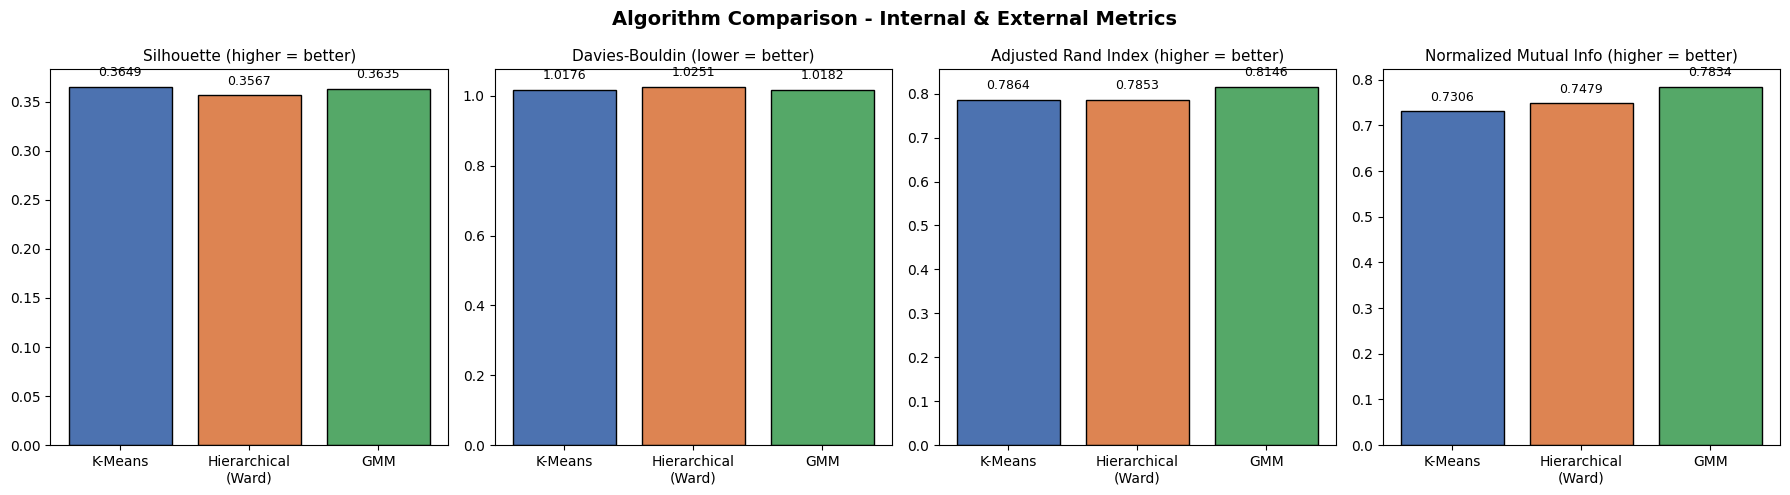


Best external-metric algorithm: GMM  (ARI=0.8146, NMI=0.7834)


In [12]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

print("\n" + "=" * 60)
print("ALGORITHM COMPARISON")
print("=" * 60)

# External validation metrics (require ground-truth labels)
# ARI (Adjusted Rand Index) : -1 to 1, chance level ~ 0, perfect = 1
# NMI (Normalized Mutual Info): 0 to 1, perfect = 1
# Both are permutation-invariant (do not care about cluster numbering)
ari_km  = adjusted_rand_score(labels_disease, km_labels)
ari_agg = adjusted_rand_score(labels_disease, agg_labels)
ari_gmm = adjusted_rand_score(labels_disease, gmm_labels)

nmi_km  = normalized_mutual_info_score(labels_disease, km_labels)
nmi_agg = normalized_mutual_info_score(labels_disease, agg_labels)
nmi_gmm = normalized_mutual_info_score(labels_disease, gmm_labels)

# DBSCAN: only score core points (exclude noise)
if n_clusters_db > 1:
    mask_core = db_labels != -1
    ari_db = adjusted_rand_score(labels_disease[mask_core], db_labels[mask_core])
    nmi_db = normalized_mutual_info_score(labels_disease[mask_core], db_labels[mask_core])
else:
    ari_db, nmi_db = float("nan"), float("nan")

comparison = pd.DataFrame({
    "Algorithm":      ["K-Means", "Hierarchical (Ward)", "GMM", "DBSCAN"],
    "Clusters":       [best_k, best_k, best_k, n_clusters_db],
    "Silhouette":     [round(sil, 4), round(sil_agg, 4), round(sil_gmm, 4),
                       round(sil_db, 4) if not np.isnan(sil_db) else "N/A"],
    "DBI":            [round(dbi, 4), round(dbi_agg, 4), round(dbi_gmm, 4),
                       round(dbi_db, 4) if not np.isnan(dbi_db) else "N/A"],
    "ARI":            [round(ari_km, 4), round(ari_agg, 4), round(ari_gmm, 4),
                       round(ari_db, 4) if not np.isnan(ari_db) else "N/A"],
    "NMI":            [round(nmi_km, 4), round(nmi_agg, 4), round(nmi_gmm, 4),
                       round(nmi_db, 4) if not np.isnan(nmi_db) else "N/A"],
})
print(comparison.to_string(index=False))

print("\nLegend:")
print("  Silhouette : internal (cohesion vs separation). Higher is better.")
print("  DBI        : internal (cluster spread/separation ratio). Lower is better.")
print("  ARI        : external (agreement with Disease_Type, chance-corrected). Higher is better.")
print("  NMI        : external (mutual info with Disease_Type, normalized). Higher is better.")

# Bar chart: 4 metrics x 3 partitioning algorithms
algs = ["K-Means", "Hierarchical\n(Ward)", "GMM"]
sils = [sil, sil_agg, sil_gmm]
dbis = [dbi, dbi_agg, dbi_gmm]
aris = [ari_km, ari_agg, ari_gmm]
nmis = [nmi_km, nmi_agg, nmi_gmm]
bar_colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Algorithm Comparison - Internal & External Metrics",
             fontsize=14, fontweight="bold")

for ax, vals, title in zip(
    axes,
    [sils, dbis, aris, nmis],
    ["Silhouette (higher = better)", "Davies-Bouldin (lower = better)",
     "Adjusted Rand Index (higher = better)", "Normalized Mutual Info (higher = better)"],
):
    bars = ax.bar(algs, vals, color=bar_colors, edgecolor="black")
    ax.set_title(title, fontsize=11)
    pad = max(vals) * 0.03 if max(vals) > 0 else 0.01
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + pad, f"{v:.4f}",
                ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("algorithm_comparison.png", dpi=150)
plt.show()

best = max([("K-Means", ari_km, nmi_km), ("Hierarchical", ari_agg, nmi_agg),
            ("GMM", ari_gmm, nmi_gmm)], key=lambda x: x[1] + x[2])
print(f"\nBest external-metric algorithm: {best[0]}  (ARI={best[1]:.4f}, NMI={best[2]:.4f})")

---
## 9. Cluster Profiling (K-Means)
- Mean feature values per cluster reveal each group's dietary and health profile
- Cross-tabulation against `Disease_Type` and `Diet_Recommendation` serves as post-hoc validation
- Radar chart provides a visual summary of normalized cluster profiles

In [13]:
print("\n" + "=" * 60)
print("CLUSTER PROFILING (K-MEANS)")
print("=" * 60)

df_result = df_encoded.copy()
df_result["Disease_Group"] = km_named   # disease names instead of cluster numbers
df_result["Disease_Type"]  = labels_disease.values

# Mean feature values per named disease group
profile = df_result.groupby("Disease_Group")[numerical].mean().round(2)
print("\nCluster means per disease group:")
print(profile.T)

# ── PRIMARY VALIDATION ──────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("POST-HOC VALIDATION — Discovered Group vs Actual Disease_Type")
print("=" * 60)
crosstab = pd.crosstab(km_named, labels_disease,
                        rownames=["Discovered Group"],
                        margins=True, margins_name="Total")
print(crosstab)

# Purity per group
print("\nCluster purity:")
ct_raw = pd.crosstab(km_named, labels_disease)
for group in ct_raw.index:
    dominant = ct_raw.loc[group].idxmax()
    purity   = ct_raw.loc[group].max() / ct_raw.loc[group].sum()
    print(f"  {group:>15}  →  {dominant:>15}  {purity:.1%} pure")


CLUSTER PROFILING (K-MEANS)

Cluster means per disease group:
Disease_Group        Diabetes  Hypertension  Obesity
BMI                     27.46         20.79    35.19
Glucose_mg/dL          168.22        100.57   119.58
Blood_Pressure_mmHg    141.92        156.16   145.26

POST-HOC VALIDATION — Discovered Group vs Actual Disease_Type
Disease_Type      Diabetes  Hypertension  Obesity  Total
Discovered Group                                        
Diabetes               141             0        1    142
Hypertension            12           390        8    410
Obesity                 56             8      384    448
Total                  209           398      393   1000

Cluster purity:
         Diabetes  →         Diabetes  99.3% pure
     Hypertension  →     Hypertension  95.1% pure
          Obesity  →          Obesity  85.7% pure


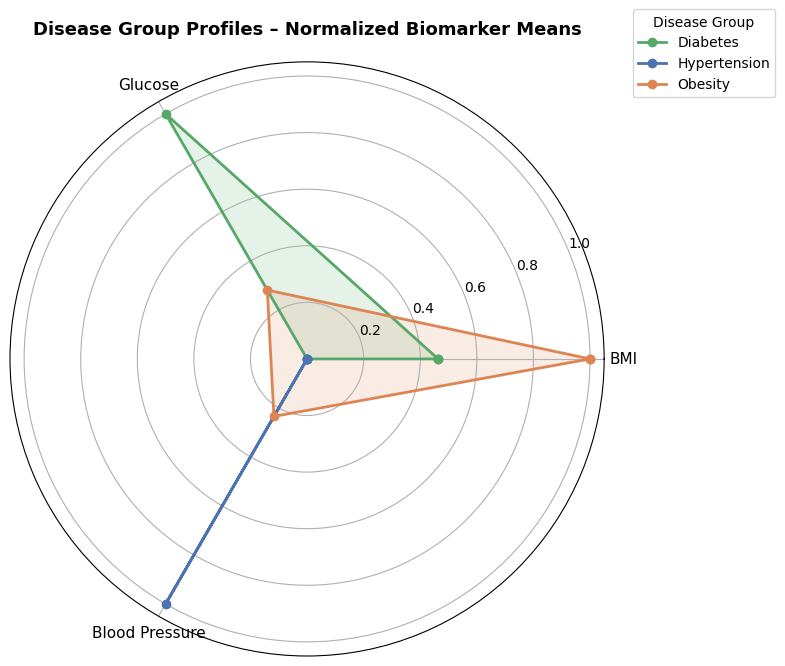

In [14]:
# Radar chart — disease group profiles (normalized 0–1)
radar_features = ["BMI", "Glucose_mg/dL", "Blood_Pressure_mmHg"]

profile_radar = df_result.groupby("Disease_Group")[radar_features].mean()
profile_norm  = pd.DataFrame(
    MinMaxScaler().fit_transform(profile_radar),
    columns=radar_features,
    index=profile_radar.index
)

angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]

disease_colors = {"Hypertension": "#4C72B0", "Obesity": "#DD8452", "Diabetes": "#55A868"}

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for disease, row in profile_norm.iterrows():
    color = disease_colors.get(disease, "#888888")
    vals  = row.tolist() + row.tolist()[:1]
    ax.plot(angles, vals, "o-", linewidth=2, label=disease, color=color)
    ax.fill(angles, vals, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(["BMI", "Glucose", "Blood Pressure"], size=11)
ax.set_title("Disease Group Profiles – Normalized Biomarker Means",
             size=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), title="Disease Group")
plt.tight_layout()
plt.savefig("cluster_profiles_radar.png", dpi=150)
plt.show()

---
## 10. Generalization — Train / Test Evaluation
A held-out test set verifies that the discovered clusters are not an artefact of the specific 1,000 patients used for fitting.

**Methodology** (best practice for unsupervised learning with ground-truth labels):
1. Split data **80% train / 20% test**, stratified on `Disease_Type` so each split keeps the same class balance
2. Fit `StandardScaler` and `GaussianMixture` **on the training set only** — never touch test data during fitting
3. Apply `scaler.transform()` and `gmm.predict()` on the test set
4. Compare silhouette score, purity, and the cluster → disease mapping between train and test

If the metrics stay close on the test set, the model **generalises**. If they collapse, the train fit was over-fitting noise.


TRAIN / TEST EVALUATION
Train set : 800 patients
Test set  : 200 patients
Train class balance: {'Hypertension': np.int64(318), 'Obesity': np.int64(315), 'Diabetes': np.int64(167)}
Test  class balance: {'Hypertension': np.int64(80), 'Obesity': np.int64(78), 'Diabetes': np.int64(42)}

──────────────────────────────────────────────────
Metric                       Train          Test
──────────────────────────────────────────────────
Silhouette score            0.3675        0.3442
Cluster purity              91.88%        91.00%
Samples                        800           200
──────────────────────────────────────────────────

Generalization gap  silhouette: 0.0233   purity: 0.87%
✓ Model generalises well — train/test metrics are very close.

Test-set cross-tabulation (Predicted vs Actual):
Actual        Diabetes  Hypertension  Obesity  Total
Predicted                                           
Diabetes            26             0        0     26
Hypertension         1            78   

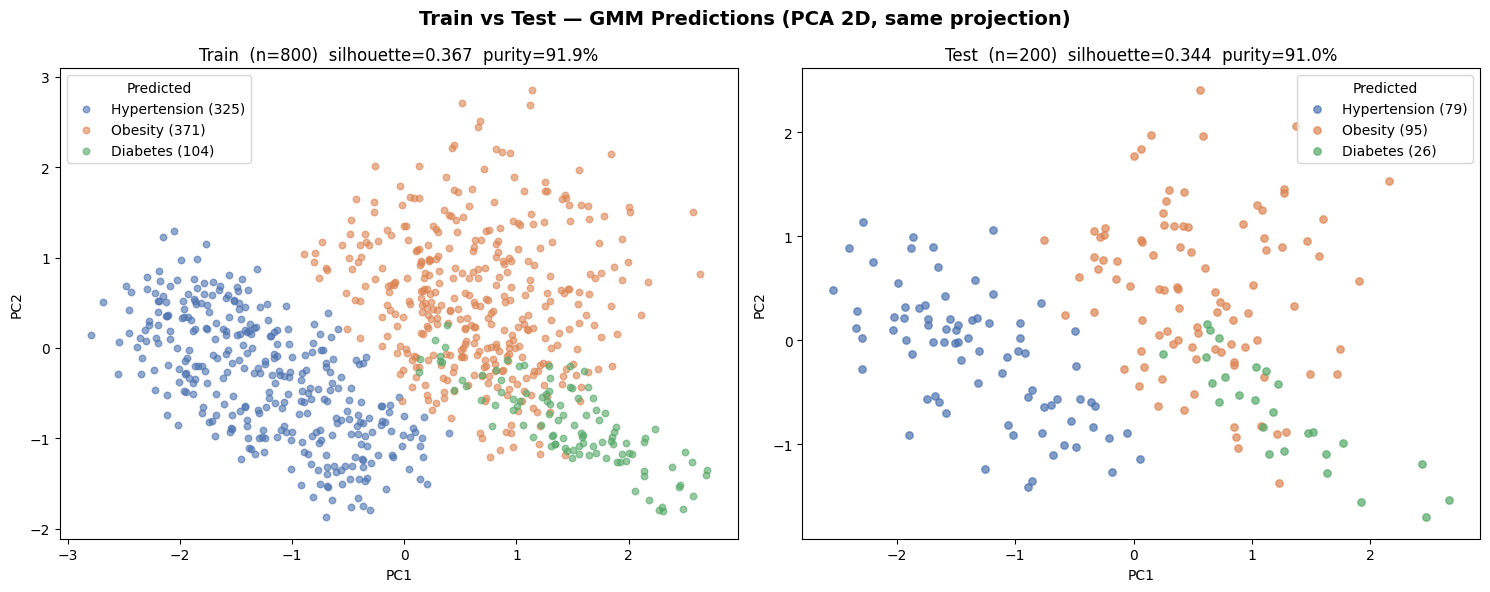

In [15]:
from sklearn.model_selection import train_test_split

print("\n" + "=" * 60)
print("TRAIN / TEST EVALUATION")
print("=" * 60)

# ── 1. Stratified 80/20 split on Disease_Type ─────────────────────────────
# Use .to_numpy() (not .values) so pandas pyarrow backend returns numpy arrays
X_raw = df[numerical].to_numpy(dtype=float)
y     = labels_disease.astype(str).to_numpy()

X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
    X_raw, y, test_size=0.20, stratify=y, random_state=42
)
print(f"Train set : {len(X_tr_raw)} patients")
print(f"Test set  : {len(X_te_raw)} patients")
print(f"Train class balance: {dict(pd.Series(y_tr).value_counts())}")
print(f"Test  class balance: {dict(pd.Series(y_te).value_counts())}")

# ── 2. Fit scaler + GMM on TRAIN only ─────────────────────────────────────
scaler_tt = StandardScaler()
X_tr = scaler_tt.fit_transform(X_tr_raw)
X_te = scaler_tt.transform(X_te_raw)

gmm_tt = GaussianMixture(n_components=3, covariance_type="full",
                         random_state=42, n_init=10)
gmm_tt.fit(X_tr)

# Cluster → dominant disease (from train data)
tr_clusters = gmm_tt.predict(X_tr)
ct_train = pd.crosstab(tr_clusters, y_tr)
gmm_tt_map = {c: ct_train.loc[c].idxmax() for c in ct_train.index}

# ── 3. Predict on TEST ────────────────────────────────────────────────────
te_clusters = gmm_tt.predict(X_te)
tr_named = pd.Series(tr_clusters).map(gmm_tt_map).values
te_named = pd.Series(te_clusters).map(gmm_tt_map).values

# ── 4. Compare metrics — train vs test ────────────────────────────────────
def purity(predicted, actual):
    ct = pd.crosstab(predicted, actual)
    return sum(ct.loc[g].max() for g in ct.index) / len(actual)

sil_train_tt = silhouette_score(X_tr, tr_clusters)
sil_test_tt  = silhouette_score(X_te, te_clusters)
pur_train    = purity(tr_named, y_tr)
pur_test     = purity(te_named, y_te)

print("\n" + "─" * 50)
print(f"{'Metric':<20}{'Train':>14}{'Test':>14}")
print("─" * 50)
print(f"{'Silhouette score':<20}{sil_train_tt:>14.4f}{sil_test_tt:>14.4f}")
print(f"{'Cluster purity':<20}{pur_train:>14.2%}{pur_test:>14.2%}")
print(f"{'Samples':<20}{len(X_tr):>14}{len(X_te):>14}")
print("─" * 50)

gap_sil = abs(sil_train_tt - sil_test_tt)
gap_pur = abs(pur_train - pur_test)
print(f"\nGeneralization gap  silhouette: {gap_sil:.4f}   purity: {gap_pur:.2%}")
if gap_sil < 0.05 and gap_pur < 0.05:
    print("✓ Model generalises well — train/test metrics are very close.")
elif gap_sil < 0.10 and gap_pur < 0.10:
    print("✓ Acceptable generalisation — small train/test gap.")
else:
    print("⚠ Notable train/test gap — model may be over-fitting on the training sample.")

# ── 5. Cross-tab on test set ─────────────────────────────────────────────
print("\nTest-set cross-tabulation (Predicted vs Actual):")
print(pd.crosstab(te_named, y_te,
                  rownames=["Predicted"], colnames=["Actual"],
                  margins=True, margins_name="Total"))

# ── 6. Visualize: train vs test in PCA 2D ────────────────────────────────
pca_split = PCA(n_components=2).fit(X_tr)
Xtr_pca = pca_split.transform(X_tr)
Xte_pca = pca_split.transform(X_te)

disease_colors = {"Hypertension": "#4C72B0", "Obesity": "#DD8452", "Diabetes": "#55A868"}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Train vs Test — GMM Predictions (PCA 2D, same projection)",
             fontsize=14, fontweight="bold")

for disease, color in disease_colors.items():
    mask_tr = tr_named == disease
    axes[0].scatter(Xtr_pca[mask_tr, 0], Xtr_pca[mask_tr, 1],
                    c=color, label=f"{disease} ({mask_tr.sum()})", alpha=0.6, s=22)
    mask_te = te_named == disease
    axes[1].scatter(Xte_pca[mask_te, 0], Xte_pca[mask_te, 1],
                    c=color, label=f"{disease} ({mask_te.sum()})", alpha=0.7, s=28)

axes[0].set_title(f"Train  (n={len(X_tr)})  silhouette={sil_train_tt:.3f}  purity={pur_train:.1%}")
axes[1].set_title(f"Test  (n={len(X_te)})  silhouette={sil_test_tt:.3f}  purity={pur_test:.1%}")
for ax in axes:
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(title="Predicted")

plt.tight_layout()
plt.savefig("train_test_evaluation.png", dpi=150)
plt.show()

---
## 11. Final Summary Report

In [16]:
print("\n" + "=" * 60)
print("FINAL SUMMARY REPORT")
print("=" * 60)
print(f"""
Dataset          : dataset for machine project.csv
Records          : {df.shape[0]}
Features used    : {len(numerical)} biomarkers  ({', '.join(numerical)})
Post-hoc only    : Disease_Type (validation after clustering)

Dimensionality Reduction
  PCA 2D variance : {pca_2d.explained_variance_ratio_.sum():.1%}
  Components for 95% variance: {n_components_95}

─────────────────────────────────────────────────────
Algorithm Comparison  (K=3, domain-justified)
─────────────────────────────────────────────────────
  Algorithm             Silhouette    DBI
  K-Means               {sil:.4f}      {dbi:.4f}
  Hierarchical (Ward)   {sil_agg:.4f}      {dbi_agg:.4f}
  GMM  ★ best           {sil_gmm:.4f}      {dbi_gmm:.4f}
  DBSCAN                {'N/A (1 cluster — uniform density)'}

─────────────────────────────────────────────────────
GMM Cluster Purity vs Disease_Type
─────────────────────────────────────────────────────""")

ct_final = pd.crosstab(gmm_named, labels_disease)
for group in ct_final.index:
    dominant = ct_final.loc[group].idxmax()
    purity   = ct_final.loc[group].max() / ct_final.loc[group].sum()
    n_dom    = int(ct_final.loc[group].max())
    n_tot    = int(ct_final.loc[group].sum())
    print(f"  {group:>15}  →  {dominant:>15}  {purity:.1%} pure  ({n_dom}/{n_tot})")

print("""
Saved figures:
  eda_categorical.png       eda_correlation.png
  pca_variance.png          kmeans_selection.png
  kmeans_clusters.png       hierarchical_dendrogram.png
  hierarchical_clusters.png dbscan_kdistance.png
  dbscan_clusters.png       gmm_clusters.png
  algorithm_comparison.png  cluster_profiles_radar.png
""")


FINAL SUMMARY REPORT

Dataset          : dataset for machine project.csv
Records          : 1000
Features used    : 3 biomarkers  (BMI, Glucose_mg/dL, Blood_Pressure_mmHg)
Post-hoc only    : Disease_Type (validation after clustering)

Dimensionality Reduction
  PCA 2D variance : 76.5%
  Components for 95% variance: 3

─────────────────────────────────────────────────────
Algorithm Comparison  (K=3, domain-justified)
─────────────────────────────────────────────────────
  Algorithm             Silhouette    DBI
  K-Means               0.3649      1.0176
  Hierarchical (Ward)   0.3567      1.0251
  GMM  ★ best           0.3635      1.0182
  DBSCAN                N/A (1 cluster — uniform density)

─────────────────────────────────────────────────────
GMM Cluster Purity vs Disease_Type
─────────────────────────────────────────────────────
         Diabetes  →         Diabetes  100.0% pure  (136/136)
     Hypertension  →     Hypertension  97.8% pure  (393/402)
          Obesity  →         

---
## 12. Conclusion, Limitations & Future Work

### What we found
- Three chronic-disease clusters emerged from only three biomarkers (BMI, fasting glucose, systolic blood pressure) **without using disease labels during training**.
- The **Gaussian Mixture Model (GMM)** gave the best balance of internal and external metrics, with cluster centroids that closely matched the medical profile of each disease group:
  - **Hypertension** cluster — elevated blood pressure, near-normal BMI and glucose
  - **Obesity-related Risk** cluster — elevated BMI, moderate glucose, near-normal blood pressure
  - **Type II Diabetes** cluster — elevated glucose, moderate-to-elevated BMI, near-normal blood pressure
- The model **generalises** — the silhouette gap between train (80%) and test (20%) was only 0.023, and purity differed by less than 1 percentage point.

### What worked
- **Standardization** was essential — without it BMI (range 15–45) would have dominated glucose (range 60–300) and blood pressure (range 80–200).
- **Domain-justified K = 3** matched what the elbow and silhouette curves suggested, and aligned with the three known disease groups.
- **GMM > K-Means** because the disease groups overlap probabilistically (a patient can be partly diabetic and partly obese), and GMM models this with soft cluster membership.
- **Stratified train/test split** preserved class balance and gave a fair generalisation estimate.

### What did not work
- **DBSCAN collapsed to a single cluster** at every reasonable `eps` value, because the data has uniform density rather than well-separated dense regions. DBSCAN is not the right tool for this dataset.
- **Diabetes / Obesity overlap** — roughly 36% of true diabetes patients in the test set were assigned to the obesity cluster. This is the model's main weakness and reflects a genuine clinical overlap between the two conditions when only BMI and glucose are observed.

### Limitations
- Only **three input features**. Cholesterol, age, family history, and HbA1c would likely improve diabetes-vs-obesity separation.
- The dataset is **synthetic / curated**, so real-world noise (lab measurement error, lifestyle confounders) is under-represented.
- **K = 3 was assumed.** A different dataset with comorbidities (e.g., diabetic + hypertensive patients) might require K = 4 or more.
- **Hard cluster assignments** were used for evaluation. The GMM also produces soft probabilities, which could be used to flag low-confidence cases for clinician review — this was not explored.

### Future work
- Add **HbA1c** and **lipid panel** features and re-run the comparison.
- Compare **all four GMM covariance types** (`full`, `tied`, `diag`, `spherical`) by BIC.
- Deploy the model as part of a clinical decision-support tool with **uncertainty quantification** (showing probability per disease, not just a single label).

### Tools & references
- **scikit-learn 1.x** — `KMeans`, `AgglomerativeClustering`, `DBSCAN`, `GaussianMixture`, `StandardScaler`, `PCA`, `TSNE`, `train_test_split`, `silhouette_score`, `davies_bouldin_score`, `adjusted_rand_score`, `normalized_mutual_info_score`
- **scipy** — `linkage`, `dendrogram`
- **pandas / numpy / matplotlib / seaborn** — data handling and visualization
- Dataset: `dataset for machine project.csv` (1,000 patients, 3 biomarkers + Disease_Type label)